In [ ]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

ndevices = 32
import os
os.environ["XLA_FLAGS"] = f"--xla_force_host_platform_device_count={ndevices}"
os.environ["OMP_NUM_THREADS"] = f"{ndevices}"
os.environ["MKL_NUM_THREADS"] = f"{ndevices}"
os.environ["NUMEXPR_NUM_THREADS"] = f"{ndevices}"
os.environ["OPENBLAS_NUM_THREADS"] = f"{ndevices}"
os.environ["VECLIB_MAXIMUM_THREADS"] = f"{ndevices}"
os.environ["NUMBA_NUM_THREADS"] = f"{ndevices}"
os.environ["JAX_TRACEBACK_FILTERING"] = "off"

from tqdm import tqdm
import multiprocessing
import pandas as pd
import sys
import glob
from functools import partial
from astropy.io import fits, ascii
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from astropy import units as u
from astropy.table import Table
import astropy.constants as const
from astropy.coordinates import SkyCoord, concatenate
from astropy import table
from astropy.cosmology import FlatLambdaCDM, Flatw0waCDM, w0waCDM, z_at_value, wCDM, LambdaCDM
import scipy.stats as st
from scipy.optimize import minimize
from scipy.signal import fftconvolve
import warnings
import h5py
import emcee
import corner
from scipy import stats
from scipy.interpolate import interp1d

import time
plt.style.use('style.mplstyle')
from hubble_fit import *


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
hdul = fits.open('data/dr16q_prop_May01_2024.fits')
fits_data = hdul[1].data  # Assuming the data is in the first extension    
fits_data_2 = hdul[2].data  # Assuming the data is in the first extension   

In [229]:
bands = ['u', 'g', 'r', 'i', 'z']#, 'y']
bands_idx = {b: i for i, b in enumerate(bands)}

def populate_sdss_fields(d, fits_data, fits_data_2):
    i = np.argwhere(d['sdss_name'] == fits_data['SDSS_NAME']).flatten()
    if len(i) == 0:
        print(f"Warning: {d['sdss_name']} not found in SDSS data")
        return d
    i = i[0]
    if np.any(fits_data_2['PSFFLUX'][i,:] <= 0):
        return d
    d['log_mbh'] = fits_data['LOGMBH'][i]
    d['log_mbh_err'] = fits_data['LOGMBH_ERR'][i]
    d['log_ledd_ratio'] = fits_data['LOGLEDD_RATIO'][i]
    d['log_ledd_ratio_err'] = fits_data['LOGLEDD_RATIO_ERR'][i]
    d['log_lbol'] = fits_data['LOGLBOL'][i]

    d['ebv'] = fits_data['EBV'][i]
    d['M_i'] = fits_data_2['M_I'][i]
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        d['apparent_mag_z'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,4]) + 22.5
        d['apparent_mag_i'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,3]) + 22.5
        d['apparent_mag_r'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,2]) + 22.5
        d['apparent_mag_g'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,1]) + 22.5
        d['apparent_mag_u'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,0]) + 22.5
        d['apparent_mag_z_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,4])/fits_data_2['PSFFLUX'][i,4]
        d['apparent_mag_i_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,3])/fits_data_2['PSFFLUX'][i,3]
        d['apparent_mag_r_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,2])/fits_data_2['PSFFLUX'][i,2]
        d['apparent_mag_g_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,1])/fits_data_2['PSFFLUX'][i,1]
        d['apparent_mag_u_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,0])/fits_data_2['PSFFLUX'][i,0]
        d['color'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i, 0] / fits_data_2['PSFFLUX'][i, 3])
    if any(issubclass(warning.category, RuntimeWarning) for warning in w):
        print(f"RuntimeWarning occurred for {d['sdss_name']}")
        print(fits_data_2['PSFFLUX'][i,:])
        print(w)
    return d


def read_quasars_from_hdf5(file_path):
    quasar_list = []

    hdul = fits.open('data/dr16q_prop_May01_2024.fits')
    fits_data = hdul[1].data  # Assuming the data is in the first extension    
    fits_data_2 = hdul[2].data  # Assuming the data is in the first extension    


    with h5py.File(file_path, "r") as hdf:
        for group_name in tqdm(hdf.keys(), desc="Reading quasars from HDF5"):
            group = hdf[group_name]
            quasar = {"object_id": group_name}
            for key, value in group.attrs.items():
                quasar[key] = value
            for sub_group_name in group.keys():
                sub_group = group[sub_group_name]
                quasar[sub_group_name] = {sub_key: sub_group[sub_key][...] for sub_key in sub_group.keys()}
            populate_sdss_fields(quasar, fits_data, fits_data_2)
            quasar_list.append(quasar)
    return quasar_list

In [ ]:
df_pantheon = pd.read_csv('https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat?raw=true',
                        sep=r'\s+')

In [234]:


hdul = fits.open('data/dr16q_prop_May01_2024.fits')
fits_data = hdul[1].data  # Assuming the data is in the first extension    
fits_data_2 = hdul[2].data  # Assuming the data is in the first extension    

#quasar_list = read_quasars_from_hdf5("data/may13_objs_tauwavelength_taublr_freebreak_newpriors_all_merged.h5")
#quasar_list = read_quasars_from_hdf5("data/may15_objs_tauwavelength_taublr_etasep_colinpriors_all_merged.h5")
quasar_list = read_quasars_from_hdf5("data/may12_objs_tauwavelength_taublr_redbands_ds4_merged.h5")
df = pd.DataFrame(quasar_list)
df = df.drop(columns=['mags', 'times', 'magerrs'])
# Remove infinite values from numeric columns
columns_with_nans = df.columns[df.isna().any()].tolist()
print("Columns with NaNs:", columns_with_nans)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].where(~np.isinf(df[numeric_cols]), np.nan)
df = df.dropna()

df = df[df['ebv'] < 0.05]
df_agn = df
print("Number of quasars:", len(quasar_list))

Reading quasars from HDF5: 100%|██████████| 1479/1479 [00:07<00:00, 208.64it/s]

Columns with NaNs: []
Number of quasars: 1479


In [ ]:
# IGNORE THIS

bands = ['u', 'g', 'r', 'i', 'z']#, 'y']
bands_idx = {b: i for i, b in enumerate(bands)}

rejected_quasar_list = []

for q in quasar_list:
    for i, b in enumerate(q['clean_bands']):
        if not ((10**q[f'log_sigma_band'][bands_idx[b]])**2 > 0.1*(np.nanmean(q['magerrs'][b])**2 + (10**q[f'log_jitter'][i])**2)):
            rejected_quasar_list.append(q)
            break
accepted_quasar_list = [q for q in quasar_list if q not in rejected_quasar_list]
print("Number of accepted quasars:", len(accepted_quasar_list))
print("Number of rejected quasars:", len(rejected_quasar_list))
#df = pd.DataFrame(accepted_quasar_list)

Number of accepted quasars: 1058
Number of rejected quasars: 421


In [236]:


df_agn = df[df['ebv'] < 0.05]
# df_agn = df_agn[df_agn['log_tau_UV_RF'].between(2, 3.5)]
# df_agn = df_agn[df_agn['log_sigma_UV'].between(-3, -0.6)]

# df_agn = df_agn[df_agn['eta_tau1'].between(0.25, 0.35)]
# df_agn = df_agn[df_agn['eta_tau2'].between(0.2, 0.35)]
# df_agn = df_agn[df_agn['eta_A1'].between(-0.23, -0.1)]
# df_agn = df_agn[df_agn['eta_A2'].between(-0.4, -0.1)]
# df_agn = df_agn[df_agn['eta_break'].between(3.9, 4.1)]
# df_agn = df_agn[df_agn['lam_s'].between(2450, 2550)]
df_agn['color'] = df_agn['apparent_mag_i'] - df_agn['apparent_mag_r']
df_agn = df_agn[df_agn['color'].between(-1, 1)]

for k in ['log_tau_UV_RF', 'log_sigma_UV']:
    df_agn = df_agn[df_agn[f'{k}_err']/np.abs(df_agn[k]) < 0.5]

# for k in ['log_tau_UV_RF_err', 'log_sigma_UV_err', 'eta_A1_err', 'eta_A2_err', 'eta_tau1_err', 'eta_tau2_err']:
#     df_agn = df_agn[df_agn[k] < 0.4]
df_agn = df_agn.reset_index(drop=True)
len(df_agn), len(df), len(df_agn)/len(df)

(1462, 1479, 0.9885057471264368)

In [200]:
columns = ['eta_A1', 'eta_A2', 'eta_tau1', 'eta_tau2']
for col in columns:
    mean_value = df_agn[col].mean()
    print(f"Mean of {col}: {mean_value}")

Mean of eta_A1: 0.9018878638012786
Mean of eta_A2: 0.9623973435082187
Mean of eta_tau1: 0.05533561030276756
Mean of eta_tau2: -0.41501271916292876


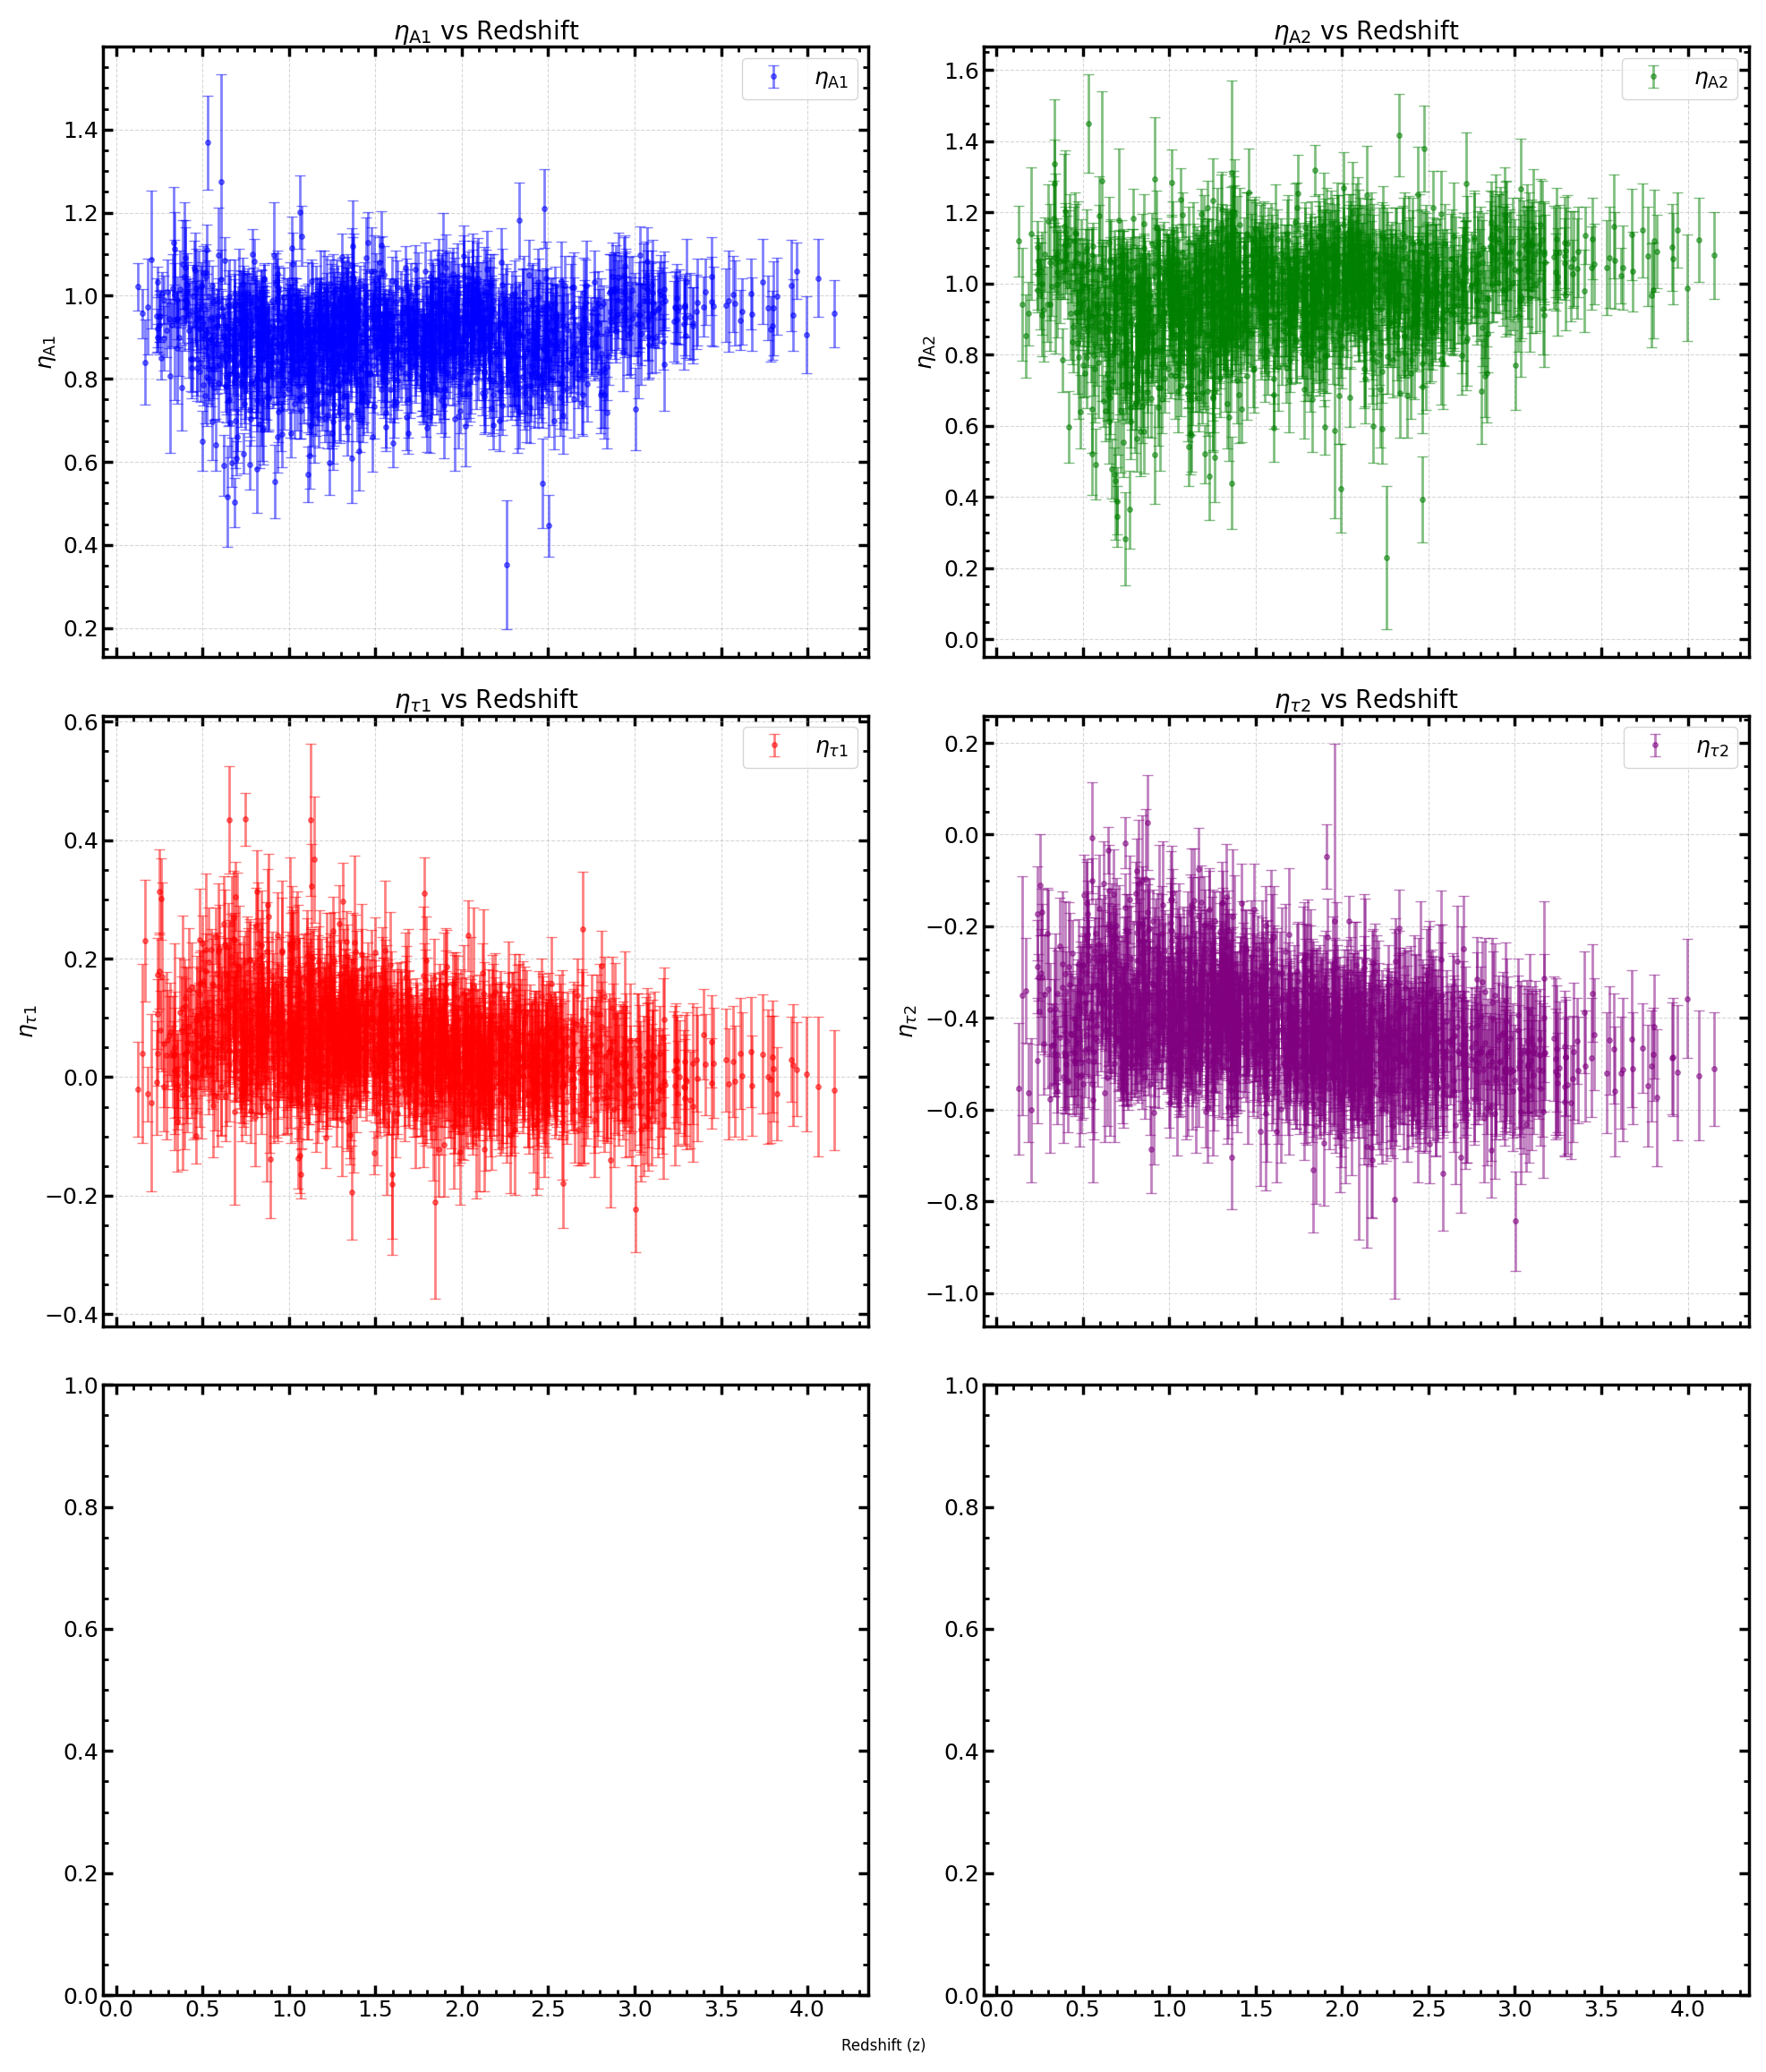

In [211]:
fig, axes = plt.subplots(3, 2, figsize=(10*2*2, 8*3), sharex=True)
axes = axes.flatten()

# Define the parameters for each plot
plot_params = [
    {'y': 'eta_A1', 'label': r'$\eta_\mathrm{A1}$', 'color': 'blue'},
    {'y': 'eta_A2', 'label': r'$\eta_\mathrm{A2}$', 'color': 'green'},
    {'y': 'eta_tau1', 'label': r'$\eta_{\tau1}$', 'color': 'red'},
    {'y': 'eta_tau2', 'label': r'$\eta_{\tau2}$', 'color': 'purple'},
    #{'y': 'eta_break', 'label': r'$\eta_\mathrm{break}$', 'color': 'purple'},
    #{'y': 'lam_s', 'label': r'$\lambda_s$', 'color': 'orange'}
]

# Loop through each parameter and create the corresponding plot
for i, params in enumerate(plot_params):
    y_err = df_agn[f"{params['y']}_err"] if f"{params['y']}_err" in df_agn.columns else None
    axes[i].errorbar(df_agn['z'], df_agn[params['y']], yerr=y_err, fmt='o', alpha=0.5, markersize=4, label=params['label'], color=params['color'])
    #axes[i].scatter(d['z'], d[params['y']], alpha=0.7, s=10, label=params['label'], color=params['color'])
    axes[i].set_ylabel(params['label'])
    axes[i].set_title(f"{params['label']} vs Redshift")
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].legend()

#fig.suptitle("removed_ebv", fontsize=28, y=0.99)
# Adjust layout and add shared x-axis label
fig.text(0.5, 0.04, 'Redshift (z)', ha='center', fontsize=12)
plt.tight_layout(rect=[0, 0.04, 1, 1])
#plt.savefig("plots/etas.pdf", format="pdf")
plt.show()

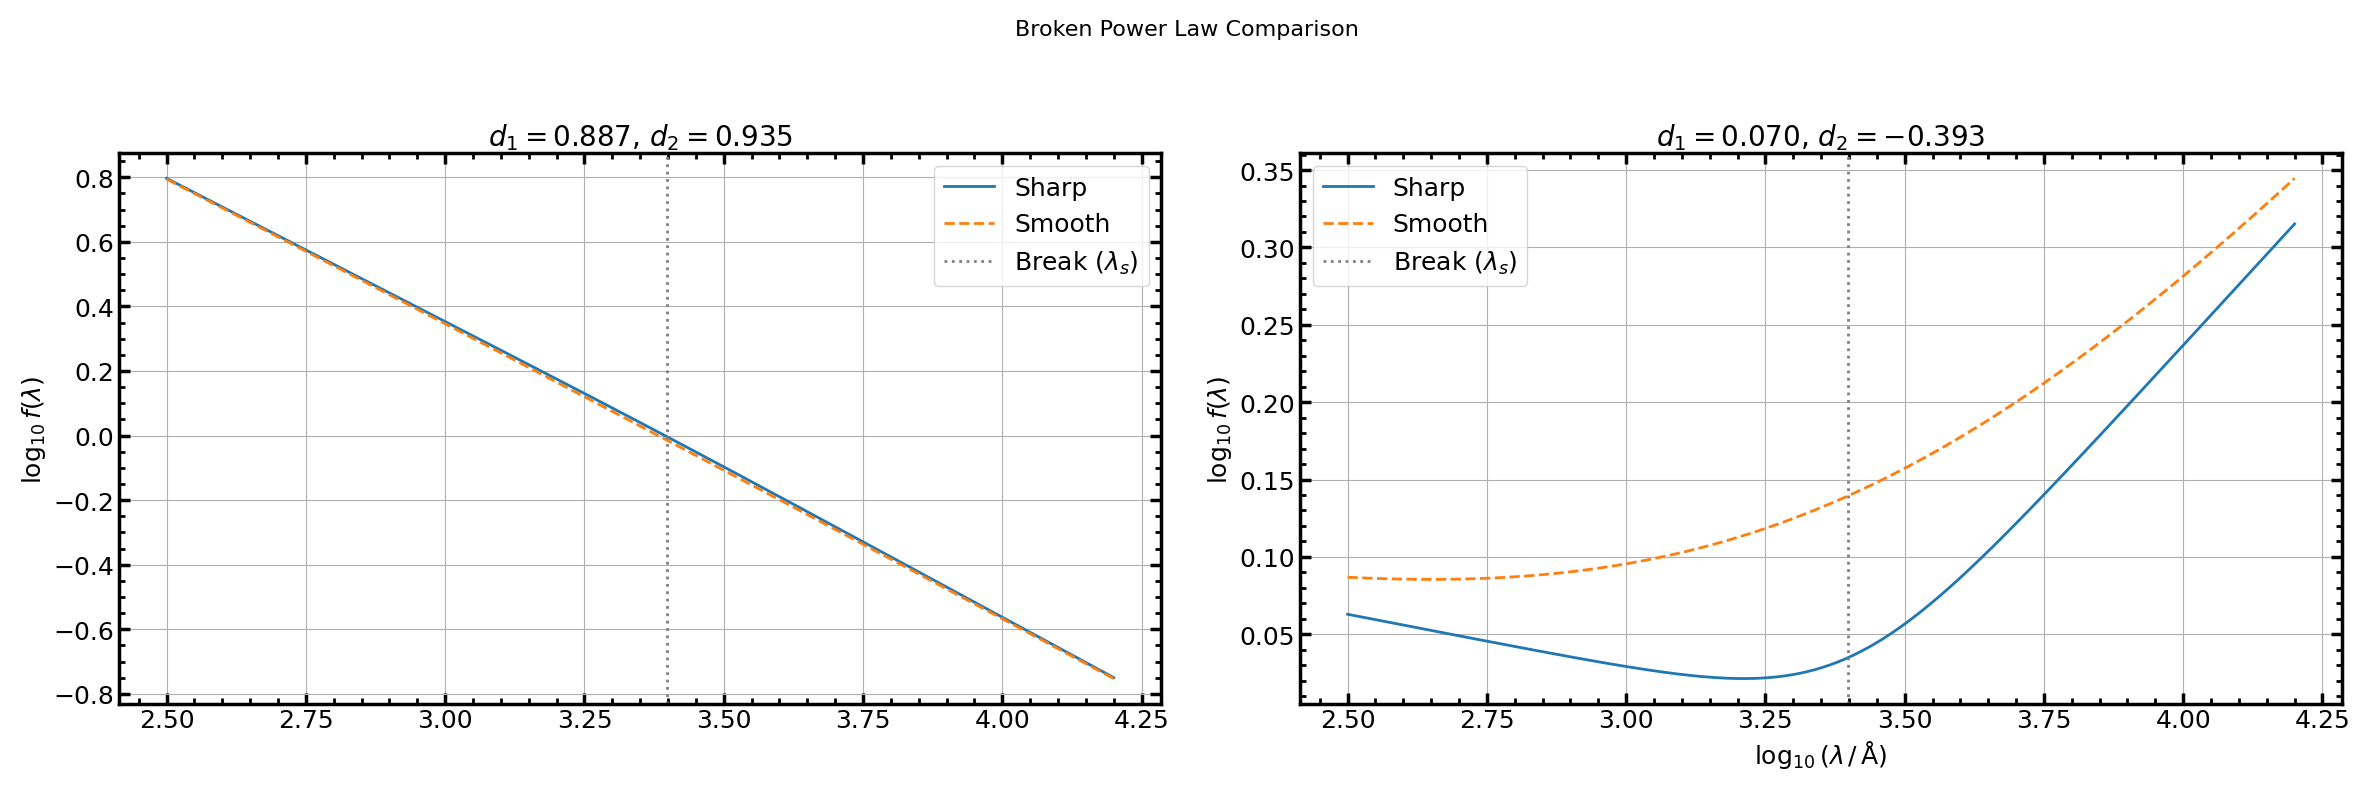

In [205]:
# Define the two broken power law functions
def log_broken_pl_colin(lam, lam_s, d1, d2):
    return np.log10( ((lam/lam_s)**d1 + (lam/lam_s)**(d2))**-1 )

def log_broken_pl_sharp(lam, lam_s, d1, d2):
    return -np.log10((lam / lam_s)**d1 + (lam / lam_s)**d2)

def log_broken_pl_smooth(lam, lam_s, d1, d2, ds=4.0):
    x = lam / lam_s
    log_f = -np.log10(
        np.power(x, d1) * np.power(1.0 + np.power(x, ds), (d2 - d1) / ds)
    )
    return log_f

def compare_broken_powerlaws_multiple(param_list):
    """
    Plots the sharp vs smooth broken power-law models for multiple sets of parameters.

    Parameters:
    - param_list: list of tuples [(d1, d2, lam_s, ds), ...]
    """
    lam = np.logspace(2.5, 4.2, 500)  # ~300 Å to 16000 Å
    log_lam = np.log10(lam)

    n = len(param_list)
    fig, axes = plt.subplots(1, n, figsize=(12*n, 8), sharex=True)

    if n == 1:
        axes = [axes]

    for ax, (d1, d2, lam_s) in zip(axes, param_list):
        y_sharp = log_broken_pl_colin(lam, lam_s, d1, d2)
        y_sharp = log_broken_pl_smooth(lam, lam_s, d1, d2, 4)
        y_smooth = log_broken_pl_smooth(lam, lam_s, d1, d2, 1)

        ax.plot(log_lam, y_sharp, label='Sharp', lw=2)
        ax.plot(log_lam, y_smooth, '--', label='Smooth', lw=2)
        ax.axvline(np.log10(lam_s), color='gray', ls=':', label=r'Break ($\lambda_s$)')
        ax.set_title(f"$d_1={d1:.3f}$, $d_2={d2:.3f}$")
        ax.set_ylabel(r'$\log_{10} f(\lambda)$')
        ax.grid(True)
        ax.legend()

    axes[-1].set_xlabel(r'$\log_{10}(\lambda\,/\,\mathrm{\AA})$')
    fig.suptitle("Broken Power Law Comparison", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Example usage
params = [
    (df['eta_A1'].mean(), df['eta_A2'].mean(), df['lam_s'].mean()),
    (df['eta_tau1'].mean(), df['eta_tau2'].mean(), df['lam_s'].mean()),
]

compare_broken_powerlaws_multiple(params)


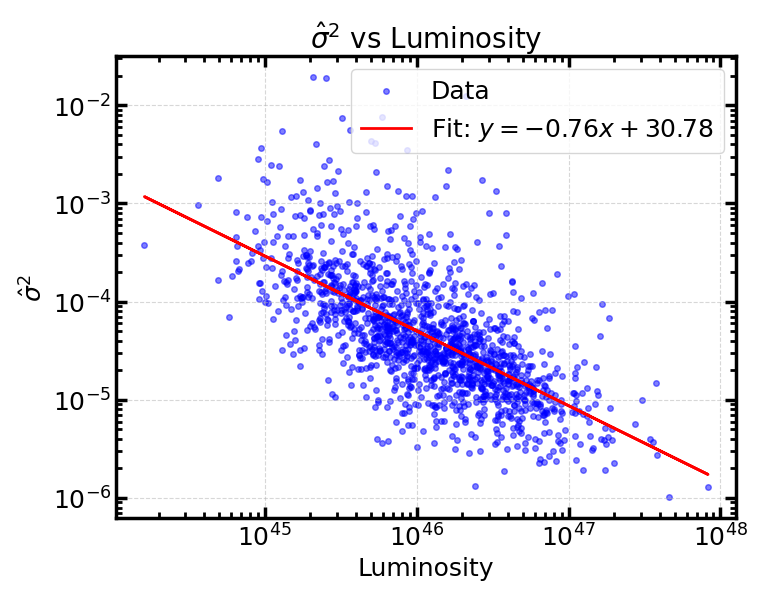

In [232]:
from scipy.stats import linregress

sigma_hat = np.sqrt((10**df['log_sigma_UV'])**2 / (10**df['log_tau_UV_RF']))
luminosity = 10**df['log_lbol']

# Perform linear regression
log_luminosity = np.log10(luminosity)
log_sigma_hat_squared = np.log10(sigma_hat**2)
slope, intercept, r_value, p_value, std_err = linregress(log_luminosity, log_sigma_hat_squared)

# Generate the fitted line
fitted_line = 10**(slope * log_luminosity + intercept)

# Plot the data and the fitted line
plt.figure(figsize=(8, 6))
plt.scatter(luminosity, sigma_hat**2, alpha=0.5, label='Data', color='blue')
plt.plot(luminosity, fitted_line, color='red', label=f'Fit: $y = {slope:.2f}x + {intercept:.2f}$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Luminosity')
plt.ylabel(r'$\hat{\sigma}^2$')
plt.title(r'$\hat{\sigma}^2$ vs Luminosity')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

100%|██████████| 50/50 [00:13<00:00,  3.70it/s]
<string>:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


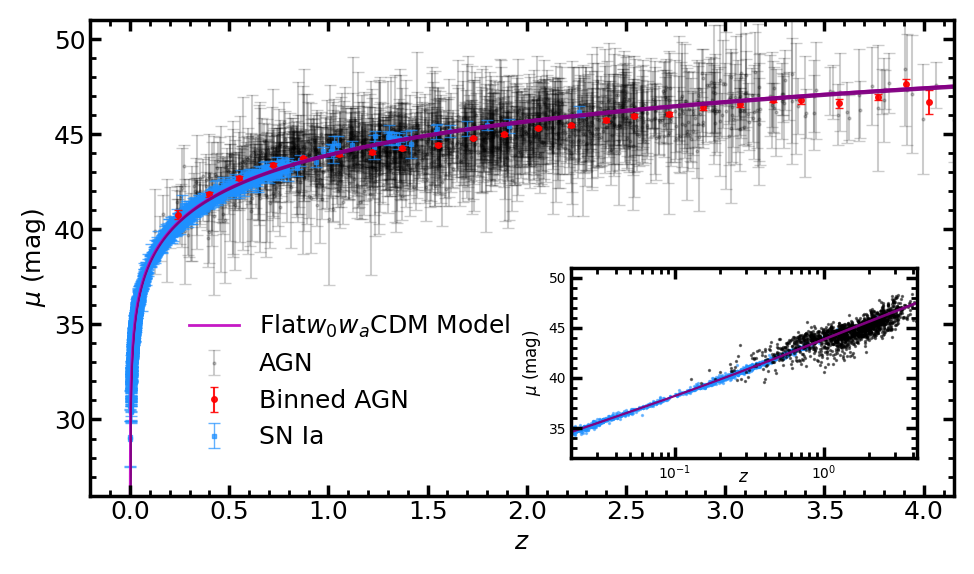

In [270]:
cosmo_model = 'Flatw0waCDM'
sampler, _ = run_mcmc_pipeline(df_agn, df_pantheon, only_sna=False, cosmo_model=cosmo_model, completeness=True)
residuals, mu_pred_std = plot_hubble(sampler, df_agn, df_pantheon, cosmo_model=cosmo_model, show=True)

100%|██████████| 50/50 [00:13<00:00,  3.68it/s]
<string>:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


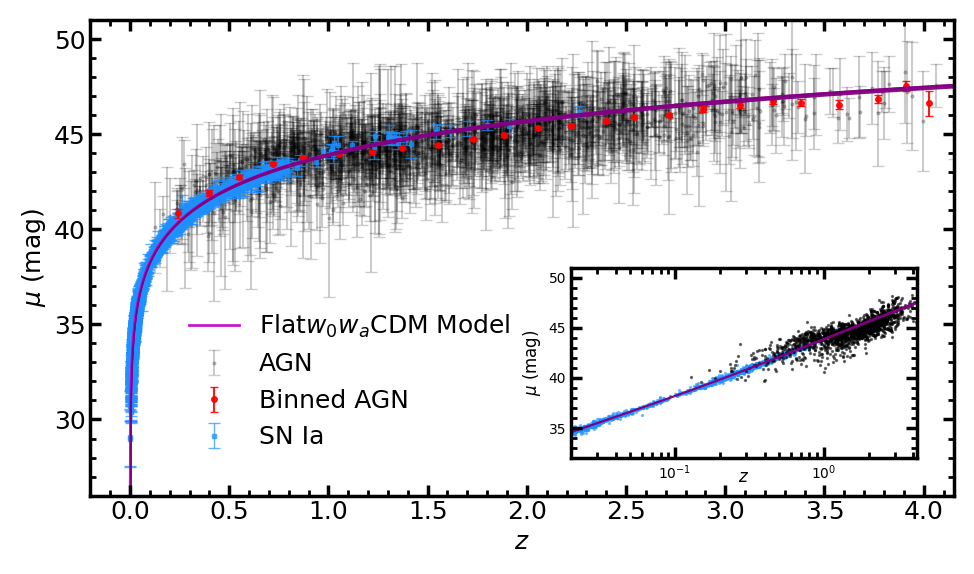

In [233]:
# def log_broken_pl(lam, lam_s, d1, d2, ds=4.0):
#     x = lam / lam_s
#     log_f = -np.log10(
#         np.power(x, d1) * np.power(1.0 + np.power(x, ds), (d2 - d1) / ds)
#     )
#     return log_f

def log_broken_pl(lam, lam_s, d1, d2, ds=4.0):
    x = lam / lam_s
    log_f = -np.log10(
        np.power(x, -d1) * np.power(1.0 + np.power(x, ds), -(d2 - d1) / ds)
    )
    return log_f

lambda_ref = 2500 # Any reference wavelength
lambda_s_RF = df_agn["lam_s"]

ds = 3
eta_A1 = df_agn['eta_A1'].mean()
eta_A2 = df_agn['eta_A2'].mean()
eta_tau1 = df_agn['eta_tau1'].mean()
eta_tau2 = df_agn['eta_tau2'].mean()

# eta_A1 = -0.9
# eta_A2 = -0.96
# eta_tau1 = 0.055
# eta_tau2 = 0.415

df_agn['log_sigma_UV'] = df_agn['log_sigma'] + log_broken_pl(lambda_ref, lambda_s_RF, eta_A1, eta_A2, ds=ds)
df_agn['log_tau_UV_RF'] = df_agn['log_tau'] - np.log10(1 + df_agn['z']) + log_broken_pl(lambda_ref, lambda_s_RF, eta_tau1, eta_tau2, ds=ds)

/home/dutra/dev/eztaox/venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/dutra/dev/eztaox/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/dutra/dev/eztaox/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/dutra/dev/eztaox/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/dutra/dev/eztaox/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/dutra/dev/eztaox/venv/lib/python3.13/site-packages/numpy/_core/_

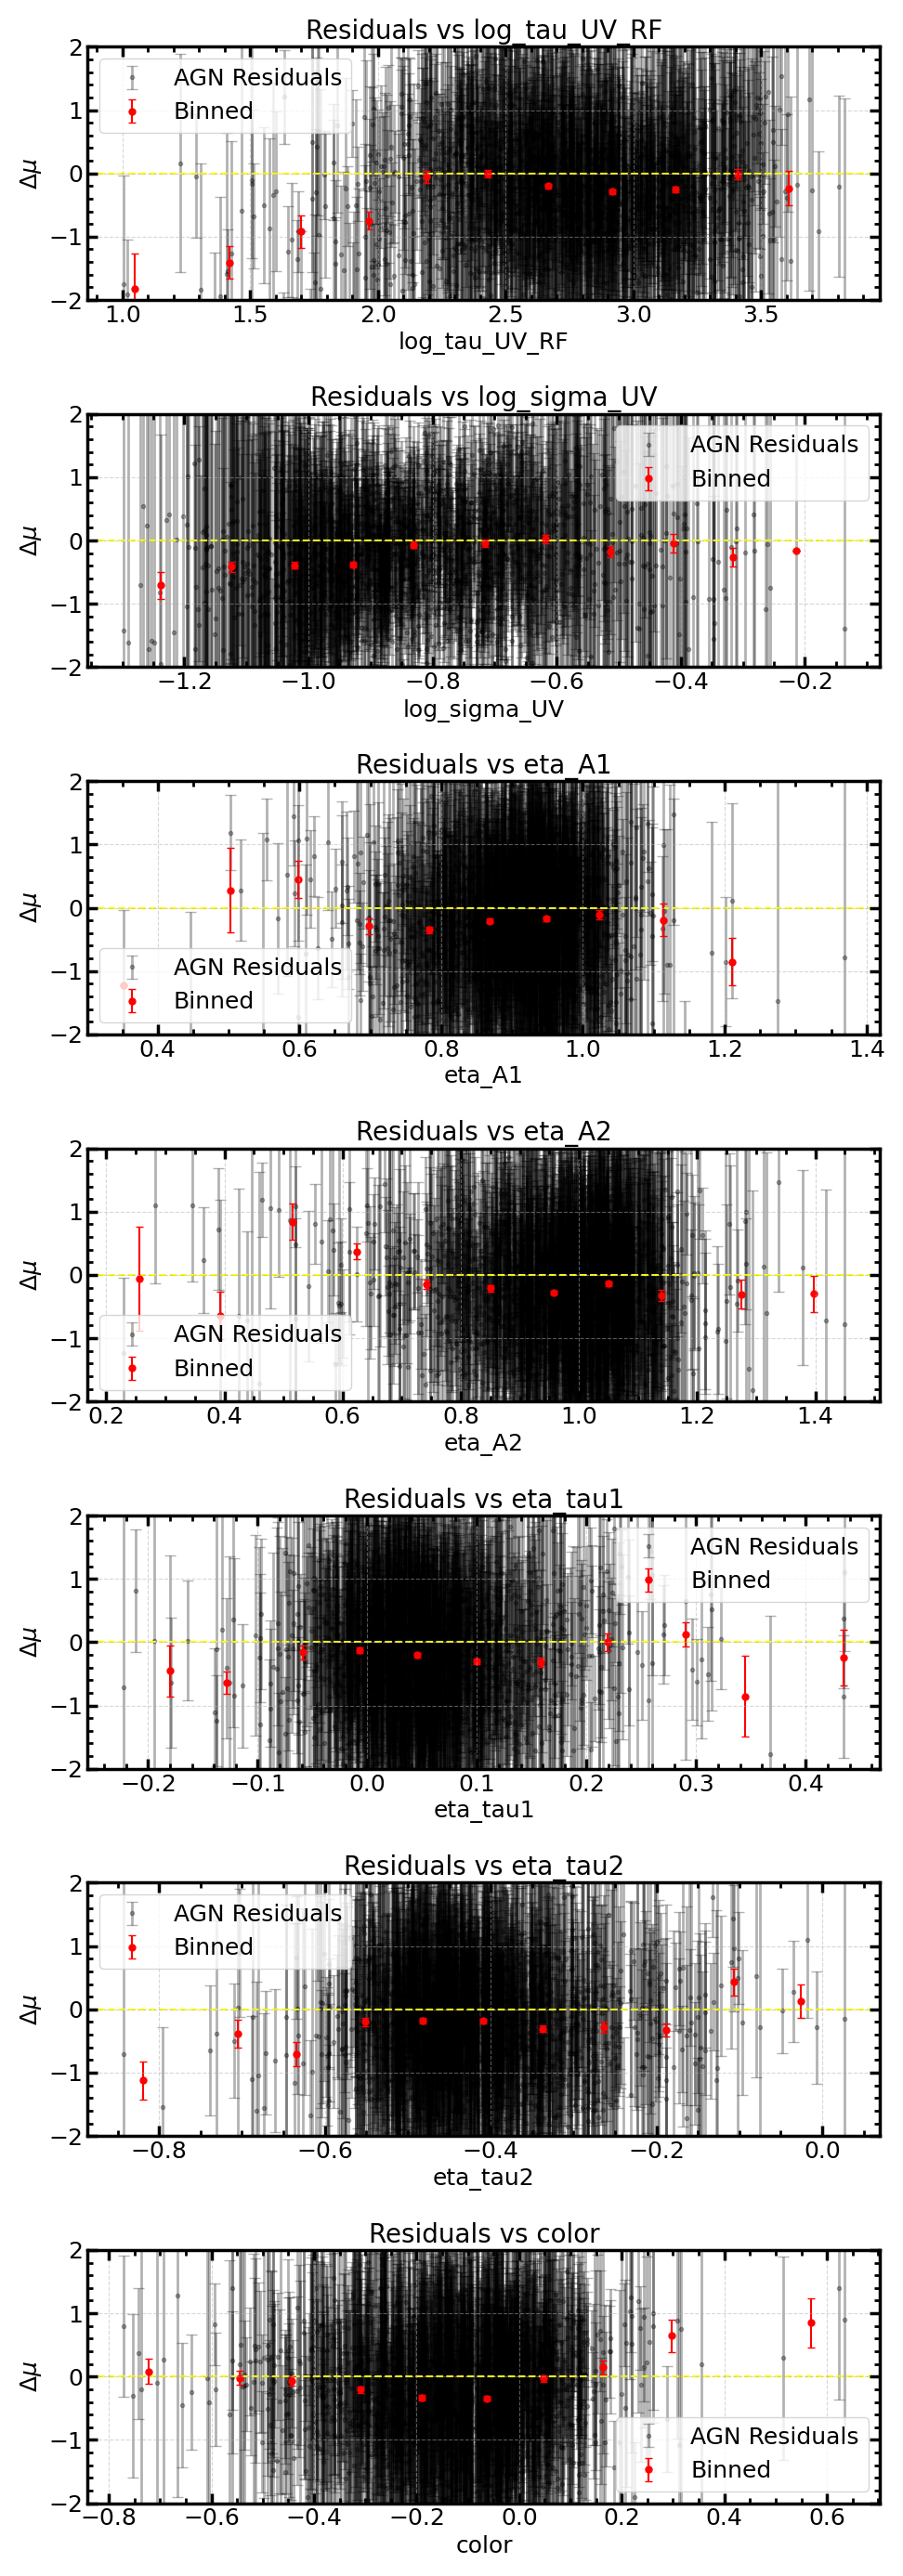

In [238]:
def plot_residuals(residual_key, ax2):
    # --- Residuals vs E(B–V) binning ---
    ebv_bins = np.linspace(df_agn[residual_key].min(), df_agn[residual_key].max(), 12)
    ebv_bin_idx = np.digitize(df_agn[residual_key], ebv_bins)
    binned_ebv = [np.median(df_agn[residual_key][ebv_bin_idx == i]) for i in range(1, len(ebv_bins))]
    binned_resid = [np.median(residuals[ebv_bin_idx == i]) for i in range(1, len(ebv_bins))]
    binned_resid_err = [np.std(residuals[ebv_bin_idx == i]) / np.sqrt(np.sum(ebv_bin_idx == i)) for i in range(1, len(ebv_bins))]
    # Residuals panel
    ax2.errorbar(df_agn[residual_key], residuals, yerr=mu_pred_std, fmt='o', color='k', alpha=0.3, markersize=3, label='AGN Residuals', zorder=-3)
    ax2.axhline(0, color="yellow", lw=1.5, linestyle="--", zorder=-2)
    ax2.errorbar(binned_ebv, binned_resid, yerr=binned_resid_err, fmt='o', color='red', lw=1.5, markersize=5, capsize=3, label='Binned', zorder=-1)
    ax2.set_xlabel(residual_key)
    ax2.set_ylabel(r"$\Delta \mu$")

residual_key_list = ['log_tau_UV_RF', 'log_sigma_UV', 'eta_A1', 'eta_A2', 'eta_tau1', 'eta_tau2', 'color']#, 'eta_break', 'lam_s', ]
nrows = len(residual_key_list)

fig, axs = plt.subplots(nrows, 1, figsize=(10, nrows*4), sharey=False)
axs = axs.flatten()
for i, residual_key in enumerate(residual_key_list):
    plot_residuals(residual_key, axs[i])
    axs[i].set_title(f"Residuals vs {residual_key}")
    axs[i].grid(True, linestyle='--', alpha=0.5)
    axs[i].legend()
    axs[i].set_ylim(-2, 2)
    #axs[i].set_xlim(-0.1, 0.5)
fig.tight_layout()

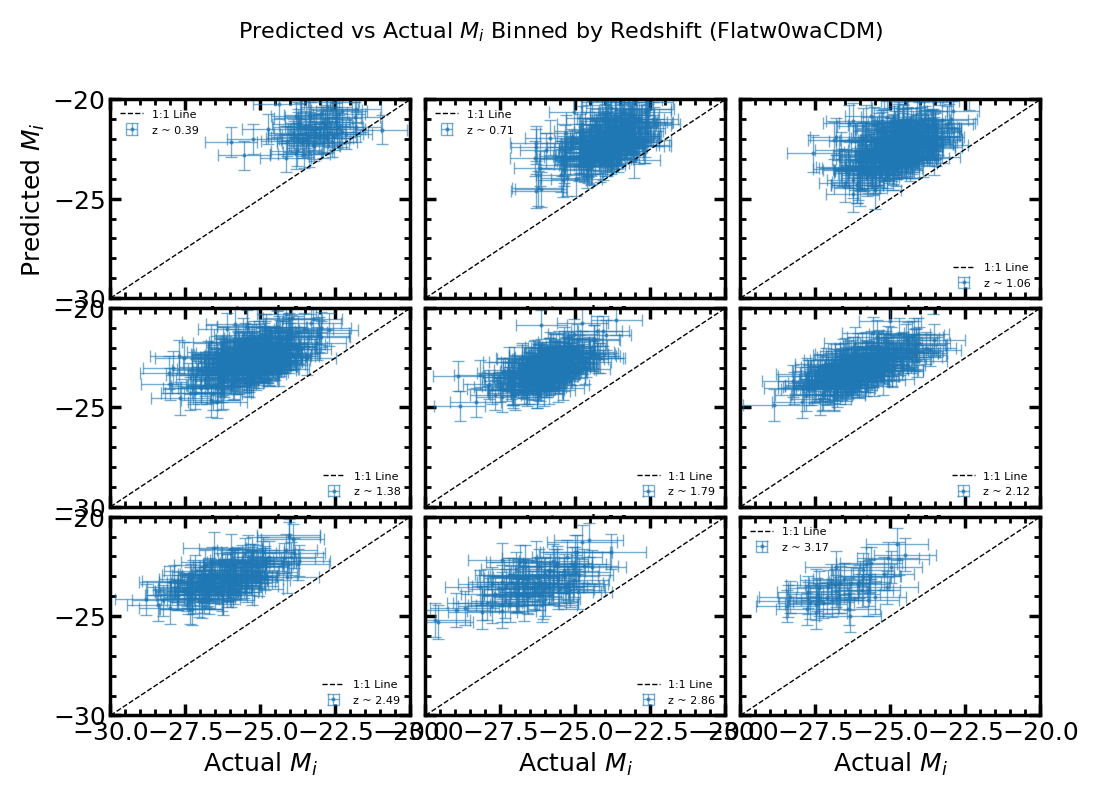

In [271]:
from hubble_fit import plot_predicted_vs_actual_Mi
plot_predicted_vs_actual_Mi(sampler, df_agn, cosmo_model=cosmo_model, show=True)